In [1]:
import pandas as pd
import numpy as np

# 1. Load the data
df = pd.read_csv('KaggleV2-May-2016.csv')

# 2. Convert date strings into true datetime values
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.normalize() # Normalize removes timestamps to keep just the date

# 3. Feature Engineering: Calculate Awaiting Days (Lead Time)
# If a patient booked and visited on the same day, lead time is 0. 
df['AwaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay'].dt.normalize()).dt.days

# Handle any negative awaiting days (caused if a booking time timestamp falls weirdly)
df['AwaitingDays'] = df['AwaitingDays'].apply(lambda x: x if x >= 0 else 0)

# 4. Feature Engineering: Extract Day of the Week
df['Weekday'] = df['AppointmentDay'].dt.day_name()

# 5. Clean Age Outliers (Remove any rows with negative ages)
df = df[df['Age'] >= 0]

# 6. Encode Target Variable (No-show: 'Yes' = 1, 'No' = 0)
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

# 7. Standardize Column Names (Fixing spelling typos to make dashboarding cleaner)
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'No-show': 'No_show'
}, inplace=True)

# Save this beautifully cleaned dataset to a new CSV file for our Power BI dashboard later
df.to_csv('cleaned_appointments.csv', index=False)

print("Data cleaning complete! Saved 110,526 rows to 'cleaned_appointments.csv'")
print(df[['ScheduledDay', 'AppointmentDay', 'AwaitingDays', 'Weekday', 'No_show']].head())

Data cleaning complete! Saved 110,526 rows to 'cleaned_appointments.csv'
               ScheduledDay            AppointmentDay  AwaitingDays Weekday  \
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00             0  Friday   
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00             0  Friday   
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00             0  Friday   
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00             0  Friday   
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00             0  Friday   

   No_show  
0        0  
1        0  
2        0  
3        0  
4        0  


Training the Decision Tree Classifier...

--- Model Performance Evaluation ---
Model Accuracy: 58.54%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.53      0.67     17642
           1       0.30      0.81      0.44      4464

    accuracy                           0.59     22106
   macro avg       0.61      0.67      0.56     22106
weighted avg       0.79      0.59      0.62     22106


--- Feature Importance Trends (What Drives No-Shows) ---
        Feature  Importance_Weight
7  AwaitingDays           0.872920
0           Age           0.105887
6  SMS_received           0.013426
5      Handicap           0.003438
4    Alcoholism           0.001719
2  Hypertension           0.001097
1   Scholarship           0.000868
3      Diabetes           0.000645


C:\Users\acer\AppData\Local\Temp\ipykernel_15964\2338794929.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Weight', y='Feature', data=feature_trends, palette='viridis')


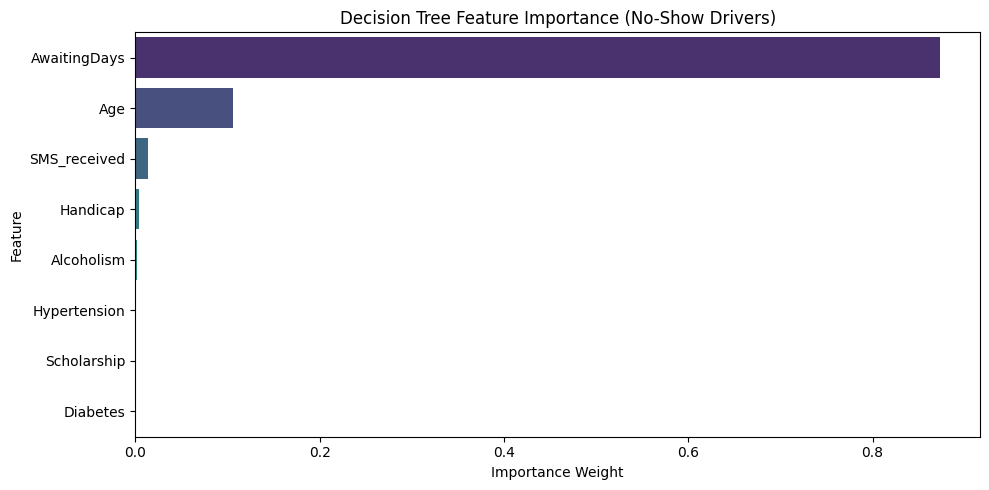

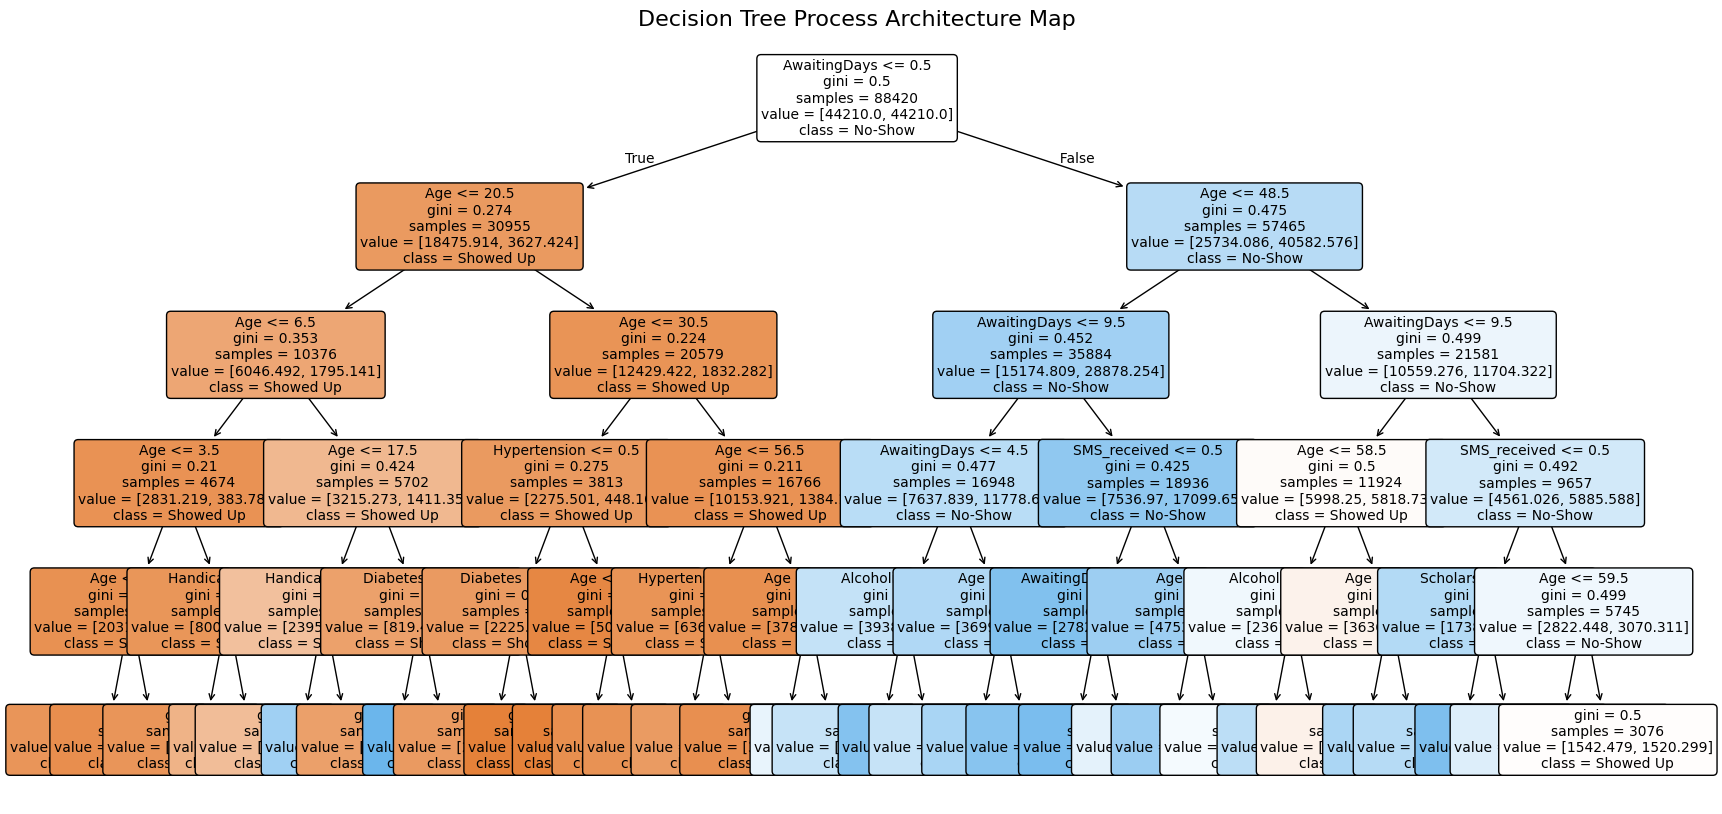

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the freshly cleaned dataset
df = pd.read_csv('cleaned_appointments.csv')

# 2. Select behavioral & operational features for training
# We drop structural IDs, names, dates, and columns that cause data leakage
features = ['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'AwaitingDays']
X = df[features]
y = df['No_show']

# Encode gender just in case we want to try it later (Optional, but let's stick to numerical metrics first)
# For this tree, we are prioritizing the metrics requested in your guide

# 3. Stratified Split (80% Train, 20% Test) to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train the Decision Tree Classifier
# We limit max_depth so the tree doesn't overfit and grows clean branches
print("Training the Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# 5. Evaluate Predictions
y_pred = dt_model.predict(X_test)
print("\n--- Model Performance Evaluation ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. Extract Feature Importances (Trends)
importances = dt_model.feature_importances_
feature_trends = pd.DataFrame({
    'Feature': features,
    'Importance_Weight': importances
}).sort_values(by='Importance_Weight', ascending=False)

print("\n--- Feature Importance Trends (What Drives No-Shows) ---")
print(feature_trends)

# ========================================================
# 📊 VISUALIZATION LABS (Save these for your report!)
# ========================================================

# Plot 1: Feature Importance Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance_Weight', y='Feature', data=feature_trends, palette='viridis')
plt.title('Decision Tree Feature Importance (No-Show Drivers)')
plt.xlabel('Importance Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Plot 2: Visualize the Decision Tree Architecture
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=features, class_names=['Showed Up', 'No-Show'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Process Architecture Map', fontsize=16)
plt.savefig('decision_tree_map.png', dpi=300)
plt.show()

In [3]:
# Load your cleaned dataset
full_df = pd.read_csv('cleaned_appointments.csv')

# Use the trained model to generate predictions for EVERY row in the dataset
X_full = full_df[['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'AwaitingDays']]
full_df['Predicted_No_Show'] = dt_model.predict(X_full)

# Save this final enhanced file for Power BI
full_df.to_csv('appointments_for_powerbi.csv', index=False)
print("Power BI dataset generated! 'appointments_for_powerbi.csv' is ready for export.")

Power BI dataset generated! 'appointments_for_powerbi.csv' is ready for export.
